In [ ]:
#       Data Importing, Merging, and Cleaning 

In [ ]:
import os
os.chdir(r"C:\Users\BAHAA\Desktop\FINAL PROHECT")

In [ ]:
import pandas as pd 
internet_sales=pd.read_excel("InternetSales.xlsx")
products=pd.read_csv("Products.csv")
customers=pd.read_json("customers.json")
sales_territory=pd.read_parquet("SalesTerritory.parquet",engine="fastparquet")

In [ ]:
internet_sales.head()

,ProductKey,OrderDate,ShipDate,CustomerKey,PromotionKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,...,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,29,6,98,19,36,100
0,310,2010-12-29,2011-01-05,21768,1,6,SO43697,1,1,1,...,0,0,2171.2942,2171.2942,NaN,NaN,NaN,3578.27,NaN,NaN
1,346,2010-12-29,2011-01-05,28389,1,7,SO43698,1,1,1,...,0,0,1912.1544,1912.1544,NaN,NaN,NaN,NaN,NaN,NaN
2,346,2010-12-29,2011-01-05,25863,1,1,SO43699,1,1,1,...,0,0,1912.1544,1912.1544,NaN,NaN,NaN,NaN,NaN,3399.9900
3,336,2010-12-29,2011-01-05,14501,1,4,SO43700,1,1,1,...,0,0,413.1463,413.1463,NaN,NaN,NaN,NaN,NaN,699.0982
4,346,2010-12-29,2011-01-05,11003,1,9,SO43701,1,1,1,...,0,0,1912.1544,1912.1544,NaN,3399.99,NaN,NaN,NaN,NaN


In [ ]:
products.head()

,ProductKey,ProductAlternateKey,ProductSubcategoryKey,WeightUnitMeasureCode,SizeUnitMeasureCode,EnglishProductName,SpanishProductName,FrenchProductName,StandardCost,FinishedGoodsFlag,...,ChineseDescription,ArabicDescription,HebrewDescription,ThaiDescription,GermanDescription,JapaneseDescription,TurkishDescription,StartDate,EndDate,Status
0,1,AR-5381,NaN,NaN,NaN,Adjustable Race,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-01,NaN,Current
1,2,BA-8327,NaN,NaN,NaN,Bearing Ball,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-01,NaN,Current
2,3,BE-2349,NaN,NaN,NaN,BB Ball Bearing,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-01,NaN,Current
3,4,BE-2908,NaN,NaN,NaN,Headset Ball Bearings,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-01,NaN,Current
4,5,BL-2036,NaN,NaN,NaN,Blade,NaN,NaN,NaN,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003-07-01,NaN,Current


In [ ]:
customers.head()

,CustomerKey,GeographyKey,CustomerAlternateKey,Title,FirstName,MiddleName,LastName,NameStyle,BirthDate,MaritalStatus,...,EnglishOccupation,SpanishOccupation,FrenchOccupation,HouseOwnerFlag,NumberCarsOwned,AddressLine1,AddressLine2,Phone,DateFirstPurchase,CommuteDistance
0,12725,171,AW00012725,NaN,Gabrielle,NaN,James,0,1916-02-10,M,...,Manual,Obrero,Ouvrier,0,2,Nonnendamm 6500,NaN,1 (11) 500 555-0125,2013-08-18,1-2 Miles
1,16455,208,AW00016455,NaN,Deb,A,Moreno,0,1917-02-09,M,...,Manual,Obrero,Ouvrier,0,2,"99, rue du Départ",NaN,1 (11) 500 555-0144,2013-03-27,0-1 Miles
2,14841,171,AW00014841,NaN,Franklin,NaN,Pal,0,1917-06-05,M,...,Manual,Obrero,Ouvrier,1,1,Wertheimer Straße 8,NaN,1 (11) 500 555-0185,2013-09-02,1-2 Miles
3,18034,160,AW00018034,NaN,Ethan,J,Robinson,0,1917-09-20,M,...,Manual,Obrero,Ouvrier,0,2,Celler Weg 5,NaN,1 (11) 500 555-0160,2013-05-21,0-1 Miles
4,14992,228,AW00014992,NaN,Dale,B,Andersen,0,1918-02-11,M,...,Manual,Obrero,Ouvrier,1,1,2844 Plymouth Drive,NaN,1 (11) 500 555-0182,2013-09-04,5-10 Miles


In [ ]:
sales_territory.head()


,SalesTerritoryKey,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,1,1,Northwest,United States,North America
1,2,2,Northeast,United States,North America
2,3,3,Central,United States,North America
3,4,4,Southwest,United States,North America
4,5,5,Southeast,United States,North America


In [ ]:
currency_columns=[29, 6, 98, 19, 36, 100]
id_columns=[i for i in internet_sales.columns if i not in currency_columns]
sales_melted=internet_sales.melt(id_vars=id_columns,value_vars=currency_columns,var_name="currencyKEY",value_name="SalesAmount")
sales_melted=sales_melted.dropna(subset="SalesAmount")
currency_dictionaire=currency_dict = {6: 'AUD',19: 'CAD',29: 'DEM',36: 'EUR',98: 'GBP',100: 'USD'}
sales_melted["currencyKEY"]=sales_melted["currencyKEY"].map(currency_dictionaire)
sales_melted


,ProductKey,OrderDate,ShipDate,CustomerKey,PromotionKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,UnitPrice,ExtendedAmount,UnitPriceDiscountPct,DiscountAmount,ProductStandardCost,TotalProductCost,currencyKEY,SalesAmount
15,311,2011-01-01,2011-01-08,13513,1,8,SO43712,1,1,1,3578.27,3578.27,0,0,2171.2942,2171.2942,DEM,3578.27
23,311,2011-01-03,2011-01-10,13264,1,8,SO43720,1,1,1,3578.27,3578.27,0,0,2171.2942,2171.2942,DEM,3578.27
28,311,2011-01-05,2011-01-12,13258,1,8,SO43725,1,1,1,3578.27,3578.27,0,0,2171.2942,2171.2942,DEM,3578.27
40,311,2011-01-08,2011-01-15,13261,1,8,SO43737,1,1,1,3578.27,3578.27,0,0,2171.2942,2171.2942,DEM,3578.27
55,311,2011-01-11,2011-01-18,13265,1,8,SO43752,1,1,1,3578.27,3578.27,0,0,2171.2942,2171.2942,DEM,3578.27
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
362383,485,2014-01-28,2014-02-04,15868,1,6,SO75122,1,1,1,21.98,21.98,0,0,8.2205,8.2205,USD,21.98
362384,225,2014-01-28,2014-02-04,15868,1,6,SO75122,2,1,1,8.99,8.99,0,0,6.9223,6.9223,USD,8.99
362385,485,2014-01-28,2014-02-04,18759,1,6,SO75123,1,1,1,21.98,21.98,0,0,8.2205,8.2205,USD,21.98
362386,486,2014-01-28,2014-02-04,18759,1,6,SO75123,2,1,1,159.00,159.00,0,0,59.4660,59.4660,USD,159.00


In [ ]:
Data_frame_finale=sales_melted.merge(customers,on="CustomerKey",how="left")
Data_frame_finale=Data_frame_finale.merge(products,on="ProductKey",how="left")
Data_frame_finale=Data_frame_finale.merge(sales_territory,on="SalesTerritoryKey",how="left")
Data_frame_finale


,ProductKey,OrderDate,ShipDate,CustomerKey,PromotionKey,SalesTerritoryKey,SalesOrderNumber,SalesOrderLineNumber,RevisionNumber,OrderQuantity,...,GermanDescription,JapaneseDescription,TurkishDescription,StartDate,EndDate,Status,SalesTerritoryAlternateKey,SalesTerritoryRegion,SalesTerritoryCountry,SalesTerritoryGroup
0,311,2011-01-01,2011-01-08,13513,1,8,SO43712,1,1,1,...,Dieses Fahrrad wird von Rennprofis gefahren. E...,レース ウィナーも愛用する機種です。Adventure Works Cycles プロフェッ...,Bu bisiklet yarışçılar tarafından kullanılmakt...,2011-07-01,2007-12-28,NaN,8,Germany,Germany,Europe
1,311,2011-01-03,2011-01-10,13264,1,8,SO43720,1,1,1,...,Dieses Fahrrad wird von Rennprofis gefahren. E...,レース ウィナーも愛用する機種です。Adventure Works Cycles プロフェッ...,Bu bisiklet yarışçılar tarafından kullanılmakt...,2011-07-01,2007-12-28,NaN,8,Germany,Germany,Europe
2,311,2011-01-05,2011-01-12,13258,1,8,SO43725,1,1,1,...,Dieses Fahrrad wird von Rennprofis gefahren. E...,レース ウィナーも愛用する機種です。Adventure Works Cycles プロフェッ...,Bu bisiklet yarışçılar tarafından kullanılmakt...,2011-07-01,2007-12-28,NaN,8,Germany,Germany,Europe
3,311,2011-01-08,2011-01-15,13261,1,8,SO43737,1,1,1,...,Dieses Fahrrad wird von Rennprofis gefahren. E...,レース ウィナーも愛用する機種です。Adventure Works Cycles プロフェッ...,Bu bisiklet yarışçılar tarafından kullanılmakt...,2011-07-01,2007-12-28,NaN,8,Germany,Germany,Europe
4,311,2011-01-11,2011-01-18,13265,1,8,SO43752,1,1,1,...,Dieses Fahrrad wird von Rennprofis gefahren. E...,レース ウィナーも愛用する機種です。Adventure Works Cycles プロフェッ...,Bu bisiklet yarışçılar tarafından kullanılmakt...,2011-07-01,2007-12-28,NaN,8,Germany,Germany,Europe
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60334,485,2014-01-28,2014-02-04,15868,1,6,SO75122,1,1,1,...,Schutzbleche zum Aufstecken passen auf fast al...,クリップオン式フェンダーは、ほとんどのマウンテン バイクに適合します。,Klipsli çamurluklar çoğu dağ bisikletine uyar.,2013-07-01,NaN,Current,6,Canada,Canada,North America
60335,225,2014-01-28,2014-02-04,15868,1,6,SO75122,2,1,1,...,"Traditionelles Design mit Klapprand, Einheitsg...",跳ね上げ式のつばを持つトラディショナルなスタイルで、フリーサイズです。,"Klasik stil, herkese uygun tek bir boyda.",2013-07-01,NaN,Current,6,Canada,Canada,North America
60336,485,2014-01-28,2014-02-04,18759,1,6,SO75123,1,1,1,...,Schutzbleche zum Aufstecken passen auf fast al...,クリップオン式フェンダーは、ほとんどのマウンテン バイクに適合します。,Klipsli çamurluklar çoğu dağ bisikletine uyar.,2013-07-01,NaN,Current,6,Canada,Canada,North America
60337,486,2014-01-28,2014-02-04,18759,1,6,SO75123,2,1,1,...,Optimaler Allzweck-Fahrradständer für die Wart...,自宅での作業にも完璧な多目的スタンドで、迅速な調整が可能なクランプと鋼構造を備えています。,Evinizde bisikletiniz üzerinde çalışmanız için...,2013-07-01,NaN,Current,6,Canada,Canada,North America


In [ ]:
Data_frame_finale.dtypes

ProductKey                             int64
OrderDate                     datetime64[us]
ShipDate                      datetime64[us]
CustomerKey                            int64
PromotionKey                           int64
                                   ...      
Status                                   str
SalesTerritoryAlternateKey             int64
SalesTerritoryRegion                  object
SalesTerritoryCountry                 object
SalesTerritoryGroup                   object
Length: 84, dtype: object

In [ ]:
Data_frame_finale[["BirthDate", "DateFirstPurchase", "StartDate", "EndDate"]].head()

,BirthDate,DateFirstPurchase,StartDate,EndDate
0,1947-03-08,2011-01-01,2011-07-01,2007-12-28
1,1961-11-20,2011-01-03,2011-07-01,2007-12-28
2,1962-08-31,2011-01-05,2011-07-01,2007-12-28
3,1962-10-03,2011-01-08,2011-07-01,2007-12-28
4,1961-07-21,2011-01-11,2011-07-01,2007-12-28


In [ ]:
Data_frame_finale["BirthDate"]=pd.to_datetime(Data_frame_finale["BirthDate"])
Data_frame_finale["DateFirstPurchase"]=pd.to_datetime(Data_frame_finale["DateFirstPurchase"])
Data_frame_finale["StartDate"]=pd.to_datetime(Data_frame_finale["StartDate"])
Data_frame_finale["EndDate"]=pd.to_datetime(Data_frame_finale["EndDate"])


In [ ]:
Data_frame_finale[["BirthDate", "DateFirstPurchase", "StartDate", "EndDate"]].dtypes

BirthDate            datetime64[us]
DateFirstPurchase    datetime64[us]
StartDate            datetime64[us]
EndDate              datetime64[us]
dtype: object

In [ ]:
Data_frame_finale["ProductSubcategoryKey"].apply(float.is_integer).all()

np.True_

In [ ]:
Data_frame_finale["ProductSubcategoryKey"]=Data_frame_finale["ProductSubcategoryKey"].astype(int)

In [ ]:
missing_values=Data_frame_finale.isna().sum()/len(Data_frame_finale)*100
print(missing_values[missing_values>50])

Title                    99.491208
Suffix                   99.990056
AddressLine2             98.168680
WeightUnitMeasureCode    74.898490
SizeUnitMeasureCode      74.898490
Size                     62.230067
SizeRange                62.230067
Weight                   74.898490
Class                    64.545319
Style                    59.815376
EndDate                  91.101941
dtype: float64


In [ ]:
Data_frame_finale=Data_frame_finale.drop(columns=["Title","Suffix","AddressLine2","WeightUnitMeasureCode","SizeUnitMeasureCode","Size","SizeRange","Weight"

,"Class","Style","EndDate"],errors='ignore')

In [ ]:
Data_frame_finale.shape

(60339, 73)

In [ ]:
missing_values_2=Data_frame_finale.isna().sum()
print(missing_values_2[missing_values_2>0])


MiddleName            25471
SpanishProductName    13135
FrenchProductName     13135
Color                 28919
Status                 5369
dtype: int64


In [ ]:
Data_frame_finale["SpanishProductName"]=Data_frame_finale["SpanishProductName"].fillna(Data_frame_finale["EnglishProductName"])
Data_frame_finale["FrenchProductName"]=Data_frame_finale["FrenchProductName"].fillna(Data_frame_finale["EnglishProductName"])

In [ ]:
Data_frame_finale["MiddleName"] = Data_frame_finale["MiddleName"].fillna("  ")
Data_frame_finale["Color"] = Data_frame_finale["Color"].fillna("  ")
Data_frame_finale["Status"] = Data_frame_finale["Status"].fillna("Current")

In [ ]:
Data_frame_finale.isna().sum().sum()

np.int64(0)

In [ ]:
text_columns=Data_frame_finale.select_dtypes(include=['string','object']).columns
for i in text_columns:
    Data_frame_finale[i]=Data_frame_finale[i].astype(str).str.strip().str.title()

In [ ]:
Data_frame_finale["currencyKEY"] = Data_frame_finale["currencyKEY"].str.upper()

In [ ]:
Data_frame_finale["currencyKEY"].unique()

<ArrowStringArray>
['DEM', 'AUD', 'GBP', 'CAD', 'USD']
Length: 5, dtype: str

In [ ]:
Data_frame_finale.isnull().sum().sum()

np.int64(0)

In [ ]:
Data_frame_finale[["SalesAmount", "UnitPrice"]].describe()

,SalesAmount,UnitPrice
count,60339.000000,60339.000000
mean,483.569591,483.569591
std,924.841524,924.841524
min,2.290000,2.290000
25%,7.950000,7.950000
50%,29.990000,29.990000
75%,539.990000,539.990000
max,3578.270000,3578.270000


In [ ]:
Data_frame_finale.duplicated().sum()

np.int64(0)

In [ ]:
# 

In [ ]:
currency_key=Data_frame_finale.groupby("currencyKEY")["SalesAmount"].agg(["sum","count"]).round(2).reset_index()
currency_key

,currencyKEY,sum,count
0,AUD,9051988.08,12988
1,CAD,1806517.44,7135
2,DEM,237784.99,76
3,GBP,3388349.69,6740
4,USD,14693465.32,33400


In [ ]:
print("SALES BBY TERRITORY GROUP ")
sales_by_territory_group=Data_frame_finale.groupby("SalesTerritoryGroup")["SalesAmount"].sum().sort_values(ascending=False).round(2).reset_index()
display(sales_by_territory_group)

SALES BBY TERRITORY GROUP 


,SalesTerritoryGroup,SalesAmount
0,North America,11367634.37
1,Pacific,9061000.58
2,Europe,8749470.57


In [ ]:
print("SALES BY  Country ")
sales_by_territory_country=Data_frame_finale.groupby("SalesTerritoryCountry")["SalesAmount"].sum().sort_values(ascending=False).round(2).reset_index()
display(sales_by_territory_country)

SALES BY  Country 


,SalesTerritoryCountry,SalesAmount
0,United States,9389789.51
1,Australia,9061000.58
2,United Kingdom,3391712.21
3,Germany,2894312.34
4,France,2463446.02
5,Canada,1977844.86


In [ ]:
print("Top 10 bests elling products")
top_selling_products=Data_frame_finale.groupby("EnglishProductName")["SalesAmount"].sum().sort_values(ascending=False).round(2).reset_index()
top_selling_products.head(10)

Top 10 bests elling products


,EnglishProductName,SalesAmount
0,"Mountain-200 Black, 46",1373469.55
1,"Mountain-200 Black, 42",1363142.09
2,"Mountain-200 Silver, 38",1339462.79
3,"Mountain-200 Silver, 46",1301100.10
4,"Mountain-200 Black, 38",1294866.14
5,"Mountain-200 Silver, 42",1257434.57
6,"Road-150 Red, 62",1187985.64
7,"Road-150 Red, 48",1159359.48
8,"Road-150 Red, 52",1055589.65
9,"Road-150 Red, 56",1037698.30


In [ ]:
customer_behavior=Data_frame_finale.groupby("EnglishOccupation")["SalesAmount"].sum().reset_index()
customer_behavior

,EnglishOccupation,SalesAmount
0,Clerical,4.641816e+06
1,Management,5.457127e+06
2,Manual,2.777533e+06
3,Professional,9.868502e+06
4,Skilled Manual,6.433128e+06


In [ ]:
# Data Visualization 

In [ ]:
import matplotlib.pyplot as plt

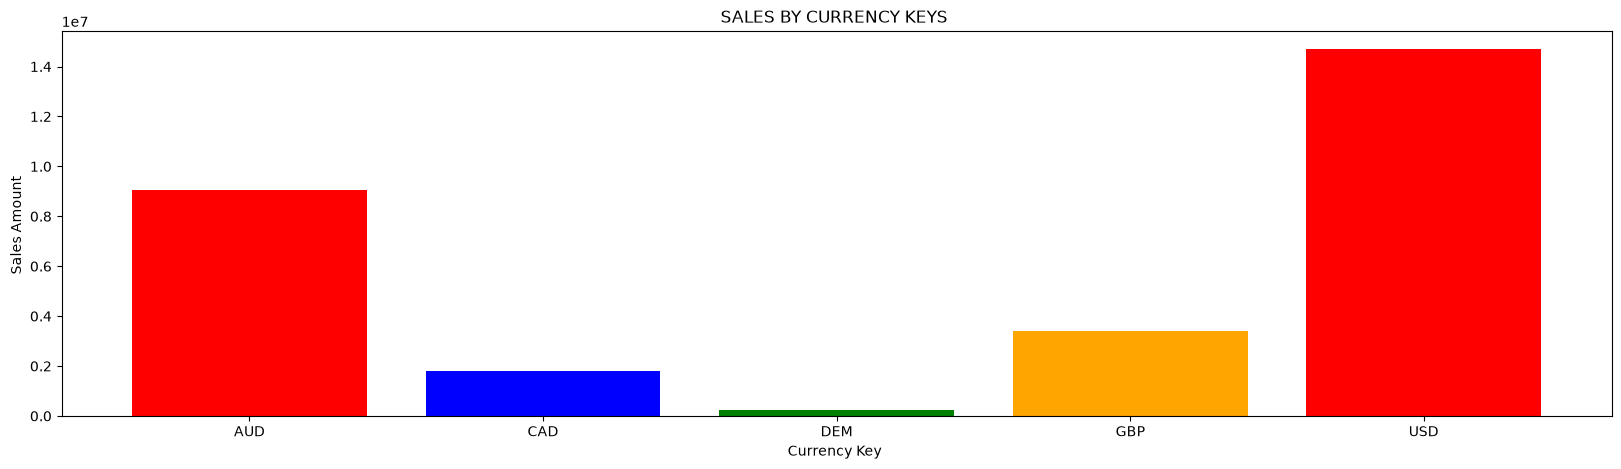

In [ ]:
fig, ax= plt.subplots(figsize=(20,5))
ax.bar(currency_key["currencyKEY"],currency_key["sum"],color=["red","blue","green","orange"])
ax.set_title("SALES BY CURRENCY KEYS ")
ax.set_xlabel("Currency Key ")
ax.set_ylabel("Sales Amount ") 
plt.show()

Interpretation: USD has the highest total sales, followed by AUD and GBP. CAD has lower sales, while DEM records the lowest sales amount. This shows that sales are mainly concentrated in USD and AUD.

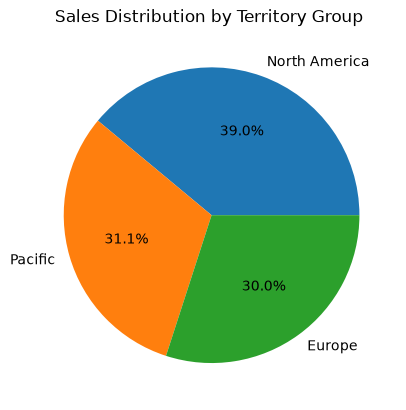

In [ ]:
fig, ax=plt.subplots()
ax.pie(sales_by_territory_group["SalesAmount"],labels=sales_by_territory_group["SalesTerritoryGroup"],autopct="%1.1f%%")
ax.set_title("Sales Distribution by Territory Group ")
plt.show()

Interpretation: North America has the highest total sales, followed by Pacific and Europe. Europe records the lowest total sales among the three territory groups.

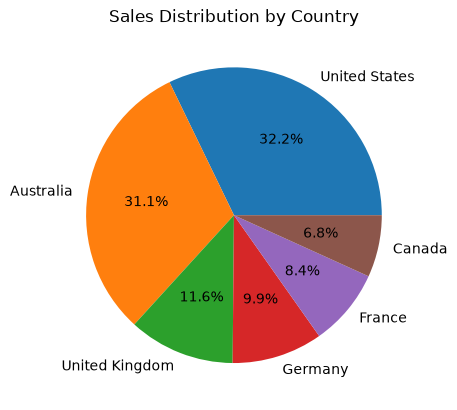

In [ ]:
fig, ax=plt.subplots()
ax.pie(sales_by_territory_country["SalesAmount"],labels=sales_by_territory_country["SalesTerritoryCountry"],autopct="%1.1f%%")
ax.set_title("Sales Distribution by Country")
plt.show()


Interpretation: Full Sales Breakdown

* United States (32.2%): Primary market leader, accounting for nearly a third of total revenue.
* Australia (31.1%): Close second place, performing almost on par with the US market.
* United Kingdom (11.6%): Top European region, delivering moderate sales volume.
* Germany (9.9%): Second largest European share, holding just under a tenth of total sales.
* France (8.4%): Third European market, generating low single-digit percentage performance.
* Canada (6.8%): Smallest market overall, contributing the lowest portion of total revenue.

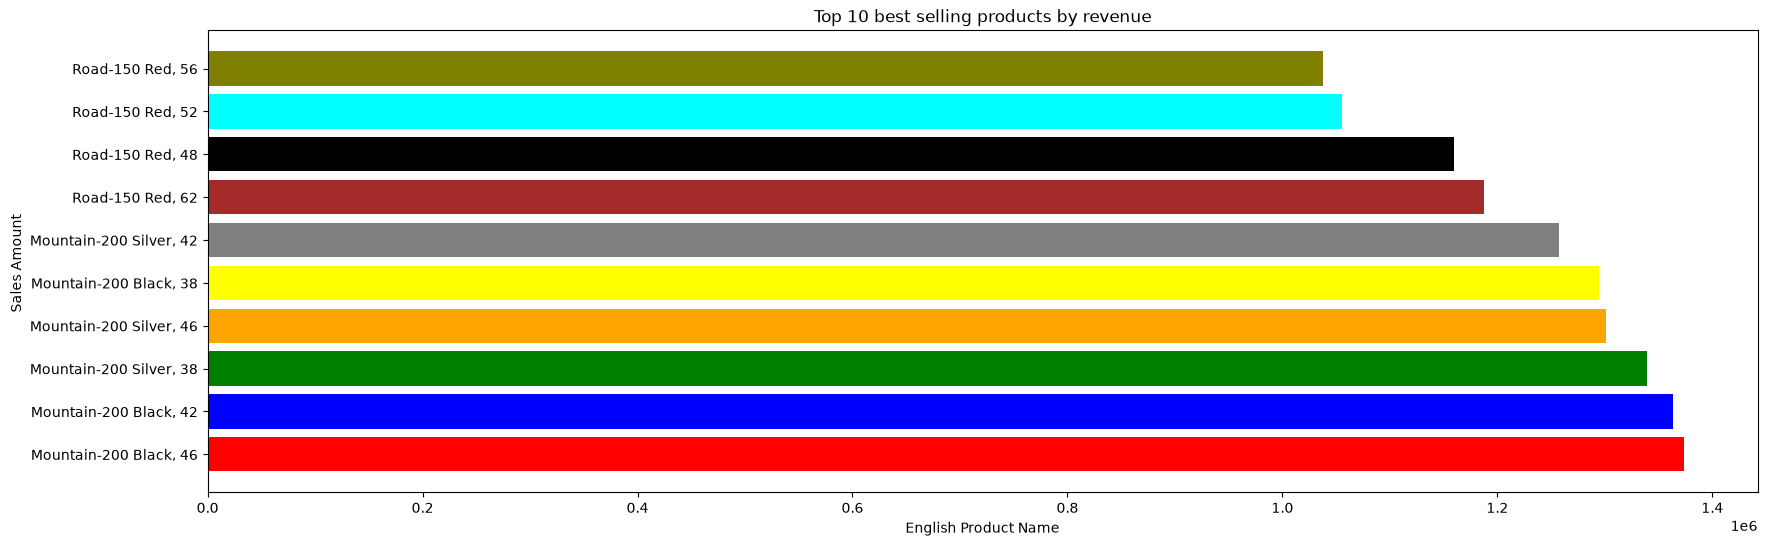

In [ ]:
top_10_products=top_selling_products.head(10).reset_index()
fig, ax= plt.subplots(figsize=(20,6))
ax.barh(top_10_products["EnglishProductName"],top_10_products["SalesAmount"],color =["red","blue","green","orange","yellow","gray","brown","black","cyan","olive"] )
ax.set_title("Top 10 best selling products by revenue")
ax.set_xlabel("English Product Name")
ax.set_ylabel("Sales Amount ") 
plt.show()

Interpretation: Mountain-200 products have the highest sales among the top 10 products, with Mountain-200 Black, 46 being the best-selling product. Road-150 Red products also have strong sales.

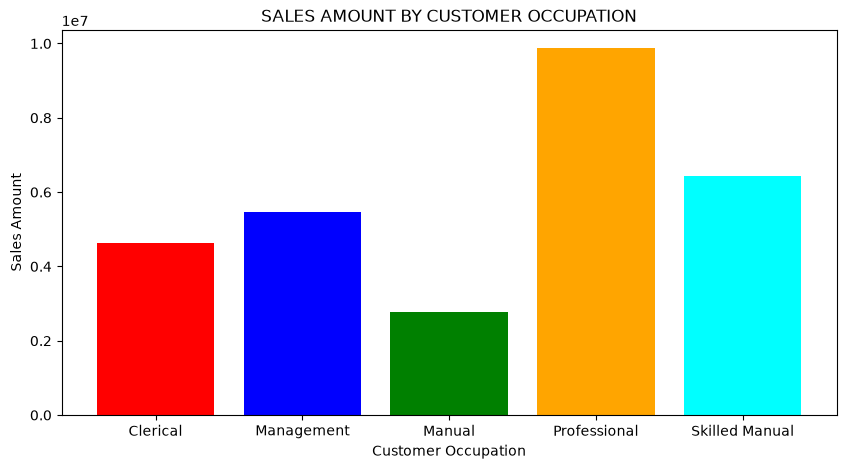

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(customer_behavior["EnglishOccupation"], customer_behavior["SalesAmount"],color=["red","blue","green","orange","cyan"])
ax.set_title("SALES AMOUNT BY CUSTOMER OCCUPATION")
ax.set_xlabel("Customer Occupation")
ax.set_ylabel("Sales Amount")

plt.show()

Interpretation: Professional customers generate the highest sales (~$9.87M), making them the primary target segment, while Manual workers contribute the lowest.